## Estimation of the Band structure in the Single Particle Bose-Hubbard model in a Lieb Lattice

The elementary cell in the Lieb Lattice is composed by three different modes $\hat{a}_{\textbf{r}},\hat{b}_{\textbf{r}},\hat{c}_{\textbf{r}}$. The hopping Interaction is defined by a Inter mode part

$\hat{H}_0=\sum_{\textbf{r}} \left(\hat{a}^{\dagger}_{\textbf{r}} \hat{b}_{\textbf{r}} + \hat{b}^{\dagger}_{\textbf{r}}\hat{a}_{\textbf{r}}\right)+\left(\hat{c}^{\dagger}_{\textbf{r}} \hat{a}_{\textbf{r}} + \hat{a}^{\dagger}_{\textbf{r}}\hat{c}_{\textbf{r}}\right)$,

and a Intra sites Interaction

$\hat{H}_1=\sum_{\textbf{r}} \left(\hat{a}^{\dagger}_{\textbf{r}+\delta { r_x}} \hat{b}_{\textbf{r}} + \hat{b}^{\dagger}_{\textbf{r}}\hat{a}_{\textbf{r}+\delta{ r_x}}\right)+\left(\hat{c}^{\dagger}_{\textbf{r}-\delta {r_y}} \hat{a}_{\textbf{r}} + \hat{a}^{\dagger}_{\textbf{r}}\hat{c}_{\textbf{r}-\delta { r_y}}\right)$,


The Hamiltonian can be factorized in $\mathbf{k}$ obtaining the following Hamiltonian

$\hat{H}= \sum_{\mathbf{k}} \begin{pmatrix}\hat{a}^{\dagger}_k & \hat{b}^{\dagger}_k & \hat{c}^{\dagger}_k \end{pmatrix}  \begin{pmatrix} 0 & J(1+\exp(i k_x a)) & J(1+\exp(-i k_y a)) \\ J(1+\exp(-i k_x a)) & 0 & 0 \\ J(1+\exp(i k_y a) ) & 0 & 0 \end{pmatrix} \begin{pmatrix} \hat{a}_k \\ \hat{b}_k \\ \hat{c}_k \end{pmatrix}$

We diagonalize the $\mathbb{H}(k)$ for each $k \in [-\pi,\pi]$ and we build up the band structure

Imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

Band structure

In [17]:
#spacing
a=1
resolution=20
# k space
k_x=np.linspace(0,2*np.pi/a,resolution)
k_y=np.linspace(0,2*np.pi/a,resolution)

# hamiltonian
hamiltonian=np.zeros((resolution,resolution,3,3),dtype=np.complex128)
hamiltonian[:,:,0,1]=(1+np.exp(1j*k_x[:,None]*a))
hamiltonian[:,:,0,2]=(1+np.exp(-1j*k_y[None,:]*a))
hamiltonian[:,:,1,0]=(1+np.exp(-1j*k_x[:,None]*a))
hamiltonian[:,:,2,0]=(1+np.exp(-1j*k_y[None,:]*a))

# eigenspectrum
e,states=np.linalg.eigh(hamiltonian)
print(e.shape)



(20, 20, 3)


Visualization

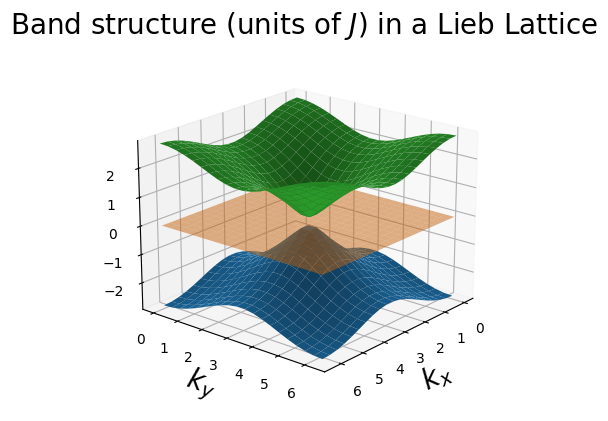

In [20]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

kx, ky = np.meshgrid(k_x, k_y)

surf_0=ax.plot_surface(kx,ky,e[:,:,0],)
surf_1=ax.plot_surface(kx,ky,e[:,:,1],alpha=0.5)
surf_2=ax.plot_surface(kx,ky,e[:,:,2],)
ax.view_init(elev=20., azim=40)
plt.title(r'Band structure (units of $J$) in a Lieb Lattice',fontsize=20)
plt.xlabel(r'$k_x$',fontsize=20)
plt.ylabel(r'$k_y$',fontsize=20)
plt.show()